### *CELL 1 — Markdown*

# Notebook 09 — Flood Extent Mapping

This notebook performs spatial flood extent mapping for Lake Victoria regulation scenarios using raster-based inundation analysis.

The analysis compares three scenarios:

1. **Observed scenario**  
   Historical lake levels and dam releases.

2. **Agreed Curve counterfactual scenario**  
   Simulated lake levels assuming dam releases strictly followed the Agreed Curve rule.

3. **Optimized rule scenario**  
   Lake levels simulated under the optimized rule curve derived in Notebook 06.

Flood extent is computed using the surrounding-land DEM (`dem_kyoganile`) and raster-based inundation logic:

A grid cell is considered flooded when:

\[
\text{DEM elevation} \le \text{water surface elevation}
\]

The notebook evaluates spatial flood extent under three conditions:

- **Peak flood year**
- **Mean flood season**
- **Aggregated exceedance above the 12.8 m flood threshold**

Outputs include:

- Flood extent maps for each scenario
- Comparison panels for each mapping case
- Flooded area summaries (km²)
- Tables and figures saved for thesis or journal use

### *CELL 2 — Imports + Paths*

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from IPython.display import display

# Project paths

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # LakeVictoria_Optimization

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TAB_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

BATHY_PATH = DATA_RAW / "geodata" / "LV_Bathy_V7.tif"
DEM_DIR = DATA_RAW / "dem_kyoganile"
DEM_PATH = DEM_DIR / "LVBDEM2.tif"
if not DEM_PATH.exists():
    tif_candidates = sorted(DEM_DIR.glob("*.tif"))
    if not tif_candidates:
        raise FileNotFoundError(f"No .tif found in {DEM_DIR}")
    DEM_PATH = tif_candidates[0]

print("CWD:", Path.cwd())
print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("DEM_PATH exists:", DEM_PATH.exists())
print("DEM file:", DEM_PATH)


CWD: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\notebooks
PROJECT_DIR: C:\Users\Nelson\Downloads\LakeVictoria_Optimization
DEM_PATH exists: True
DEM file: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\data\raw\dem_kyoganile\LVBDEM2.tif


### *CELL 3 — Open DEM dataset*

In [2]:
# Open DEM
with rasterio.open(DEM_PATH) as src:
    print("Driver:", src.driver)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Size:", src.width, "x", src.height)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)


Driver: GTiff
CRS: EPSG:32636
Resolution: (30.7939812570092, 30.7939812570092)
Size: 23801 x 20509
Bounds: BoundingBox(left=85689.05723319668, bottom=-444353.1548659159, right=818616.6051312727, top=187200.60673408583)
Nodata: -32768.0


### *CELL 4 — Load DEM array*

In [3]:
import numpy as np

with rasterio.open(DEM_PATH) as src:
    dem_meta = src.meta.copy()
    dem_transform = src.transform
    dem_bounds = src.bounds
    dem_crs = src.crs
    dem_res = src.res
    dem_nodata = src.nodata

    # Read directly as float32 (half memory vs float64)
    dem = src.read(1, out_dtype="float32")

# Replace nodata in-place (no extra big copy)
if dem_nodata is not None:
    dem[dem == dem_nodata] = np.nan

print("DEM min:", np.nanmin(dem))
print("DEM max:", np.nanmax(dem))
print("Shape:", dem.shape)
print("dtype:", dem.dtype)


DEM min: 952.0
DEM max: 4459.0
Shape: (20509, 23801)
dtype: float32


In [4]:
# Flooded area by water level
# Configure client-facing lookup levels in m asl.
water_levels_m_asl = [1134.5, 1135.0, 1135.5, 1136.0]

print("Configured quick flood-area lookup levels (m asl):", water_levels_m_asl)
print("Detailed flooded-area lookup table will be generated after equal-area DEM preparation.")


Configured quick flood-area lookup levels (m asl): [1134.5, 1135.0, 1135.5, 1136.0]
Detailed flooded-area lookup table will be generated after equal-area DEM preparation.


In [5]:
import numpy as np
from rasterio.windows import Window
from rasterio.warp import calculate_default_transform, reproject, Resampling

# ---- 1) Reproject DEM to metric CRS for defensible area calculations ----
TARGET_CRS = "EPSG:6933"   # Equal-area metric CRS for area accounting
TARGET_GEO_CRS = "EPSG:4326"  # Geographic CRS for map axes
AREA_CHUNK_ROWS = 256
EQ_NODATA = -9999.0

CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
EQUAL_AREA_DEM_PATH = CACHE_DIR / "09_dem_equal_area_epsg6933.tif"

with rasterio.open(DEM_PATH) as src:
    src_nodata = src.nodata
    src_crs = src.crs
    src_transform = src.transform
    src_bounds = src.bounds
    src_width, src_height = src.width, src.height

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, TARGET_CRS, src_width, src_height, *src_bounds
    )

    if not EQUAL_AREA_DEM_PATH.exists():
        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            height=dst_height,
            width=dst_width,
            transform=dst_transform,
            crs=TARGET_CRS,
            dtype="float32",
            nodata=EQ_NODATA,
            compress="deflate",
            tiled=True,
            bigtiff="YES",
        )
        with rasterio.open(EQUAL_AREA_DEM_PATH, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src_transform,
                src_crs=src_crs,
                dst_transform=dst_transform,
                dst_crs=TARGET_CRS,
                src_nodata=src_nodata,
                dst_nodata=EQ_NODATA,
                resampling=Resampling.bilinear,
            )

dem_m = rasterio.open(EQUAL_AREA_DEM_PATH)
pixel_area_m2 = abs(dem_m.transform.a * dem_m.transform.e)
print("Equal-area DEM path:", EQUAL_AREA_DEM_PATH)
print("Reprojected DEM shape:", (dem_m.height, dem_m.width))
print("Pixel area (m2):", pixel_area_m2)

# ---- 2) Standardized client-facing datum metadata ----
REFERENCE_LEVEL_M_ASL = 1122.85
OFFICIAL_LAKE_SURFACE_AREA_KM2 = 68800.0


def iter_row_chunks(arr_or_ds, chunk_rows=AREA_CHUNK_ROWS):
    if hasattr(arr_or_ds, "read"):
        width = arr_or_ds.width
        for row0 in range(0, arr_or_ds.height, chunk_rows):
            height = min(chunk_rows, arr_or_ds.height - row0)
            window = Window(0, row0, width, height)
            chunk = arr_or_ds.read(1, window=window, masked=True).filled(np.nan).astype("float32")
            chunk[chunk == EQ_NODATA] = np.nan
            yield chunk
    else:
        for row0 in range(0, arr_or_ds.shape[0], chunk_rows):
            yield arr_or_ds[row0: row0 + chunk_rows]


def count_valid_pixels(arr_or_ds, chunk_rows=AREA_CHUNK_ROWS):
    total = 0
    for chunk in iter_row_chunks(arr_or_ds, chunk_rows=chunk_rows):
        total += int(np.count_nonzero(np.isfinite(chunk)))
    return total


def flooded_pixels_chunked(dem_metric, water_level_m_asl, chunk_rows=AREA_CHUNK_ROWS):
    total = 0
    for chunk in iter_row_chunks(dem_metric, chunk_rows=chunk_rows):
        valid = np.isfinite(chunk)
        total += int(np.count_nonzero(valid & (chunk <= water_level_m_asl)))
    return total


def flooded_area_km2_chunked(dem_metric, water_level_m_asl, chunk_rows=AREA_CHUNK_ROWS):
    flooded_pixels = flooded_pixels_chunked(dem_metric, water_level_m_asl, chunk_rows=chunk_rows)
    return flooded_pixels * pixel_area_m2 / 1e6


VALID_PIXELS_EQUAL_AREA = count_valid_pixels(dem_m)
VALID_AREA_KM2_EQUAL_AREA = VALID_PIXELS_EQUAL_AREA * pixel_area_m2 / 1e6


Equal-area DEM path: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\cache\09_dem_equal_area_epsg6933.tif
Reprojected DEM shape: (23688, 20704)
Pixel area (m2): 945.7550772884017


# CELL — Quick vertical-datum consistency check (DEM vs water-level series)

DEM valid range: 952.000 to 4459.000 m asl
DEM median estimate: 1261.000 m asl (sample step = 15)
Added reference level: 1122.85 m asl to all scenario levels



,scenario_level_relative_m,scenario_level_m_asl,dem_median_m_asl_est,difference_to_dem_median_m
Baseline_mean_level_m,10.793048,1133.643048,1261.0,127.356952
Optimized_mean_level_m,11.821867,1134.671867,1261.0,126.328133
Observed_mean_level_m,11.695278,1134.545278,1261.0,126.454722


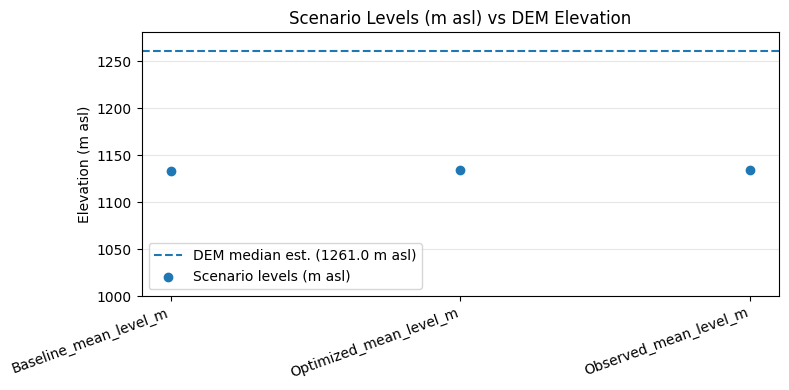

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# Ensure DEM is loaded if this cell is run independently
if "dem" not in globals():
    with rasterio.open(DEM_PATH) as src:
        dem = src.read(1, out_dtype="float32")
        dem_nodata = src.nodata
    if dem_nodata is not None:
        dem[dem == dem_nodata] = np.nan

# 1) DEM stats over valid cells
# Use a stride-based sample for the median so this diagnostic cell stays memory-safe
# on the full-resolution raster.
dem_min = float(np.nanmin(dem))
dem_max = float(np.nanmax(dem))
sample_target = 2_000_000
sample_step = max(1, int(np.sqrt(dem.size / sample_target)))
dem_sample = dem[::sample_step, ::sample_step]
dem_med = float(np.nanmedian(dem_sample))

# 2) Scenario levels converted to m asl
REFERENCE_LEVEL_M_ASL = 1122.85
scenario_levels_relative_m = {
    "Baseline_mean_level_m": 10.793048,
    "Optimized_mean_level_m": 11.821867,
    "Observed_mean_level_m": 11.695278,
}

s_relative = pd.Series(scenario_levels_relative_m, dtype="float64")
s_m_asl = s_relative + REFERENCE_LEVEL_M_ASL

# 3) Compare m asl scenario levels against DEM median
diag = pd.DataFrame({
    "scenario_level_relative_m": s_relative,
    "scenario_level_m_asl": s_m_asl,
})
diag["dem_median_m_asl_est"] = dem_med
diag["difference_to_dem_median_m"] = diag["dem_median_m_asl_est"] - diag["scenario_level_m_asl"]

print(f"DEM valid range: {dem_min:.3f} to {dem_max:.3f} m asl")
print(f"DEM median estimate: {dem_med:.3f} m asl (sample step = {sample_step})")
print(f"Added reference level: {REFERENCE_LEVEL_M_ASL:.2f} m asl to all scenario levels\n")
display(diag)

# 4) Simple visual
plt.figure(figsize=(8, 4))
plt.axhline(dem_med, linestyle="--", label=f"DEM median est. ({dem_med:.1f} m asl)")
plt.scatter(np.arange(len(s_m_asl)), s_m_asl.values, label="Scenario levels (m asl)")
plt.xticks(np.arange(len(s_m_asl)), s_m_asl.index, rotation=20, ha="right")
y_top = max(dem_med, float(s_m_asl.max())) + 20
plt.ylim(1000, y_top)
plt.ylabel("Elevation (m asl)")
plt.title("Scenario Levels (m asl) vs DEM Elevation")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# CELL — Flooded area for multiple water levels (using loaded `dem` array)

In [7]:
import numpy as np
import pandas as pd

# Flooded area lookup table (memory-safe, equal-area DEM)
water_levels_m_asl = globals().get("water_levels_m_asl", [1134.5, 1135.0, 1135.5, 1136.0])

rows = []
for wl_m_asl in water_levels_m_asl:
    flooded_pixels = flooded_pixels_chunked(dem_m, wl_m_asl, chunk_rows=AREA_CHUNK_ROWS)
    flooded_area_km2 = flooded_pixels * pixel_area_m2 / 1e6
    flooded_pct = (flooded_pixels / VALID_PIXELS_EQUAL_AREA * 100) if VALID_PIXELS_EQUAL_AREA else np.nan
    rows.append({
        "water_level_m_asl": float(wl_m_asl),
        "water_level_m": float(wl_m_asl - REFERENCE_LEVEL_M_ASL),
        "flooded_pixels": flooded_pixels,
        "flooded_area_km2": flooded_area_km2,
        "valid_area_km2": VALID_AREA_KM2_EQUAL_AREA,
        "flooded_percent": flooded_pct,
    })

flood_stats = pd.DataFrame(rows).sort_values("water_level_m_asl").reset_index(drop=True)
out_csv = TAB_DIR / "09_flooded_area_by_water_level.csv"
flood_stats.to_csv(out_csv, index=False)

print("Saved:", out_csv)
display(flood_stats)


Saved: c:\Users\Nelson\Downloads\LakeVictoria_Optimization\outputs\tables\09_flooded_area_by_water_level.csv


,water_level_m_asl,water_level_m,flooded_pixels,flooded_area_km2,valid_area_km2,flooded_percent
0,1134.5,11.65,72311160,68388.646715,264215.046458,25.883706
1,1135.0,12.15,72556621,68620.792702,264215.046458,25.971569
2,1135.5,12.65,72760608,68813.714443,264215.046458,26.044586
3,1136.0,13.15,72970032,69011.778254,264215.046458,26.119549


### *CELL 5 — Quick display helper (downsampling)*

In [8]:
from affine import Affine
from rasterio.transform import array_bounds
from rasterio.warp import transform_bounds

PLOT_STEP = 20


def quicklook(arr, step=PLOT_STEP):
    """Downsample array for fast plotting."""
    return arr[::step, ::step]


def quicklook_geo_extent(transform, shape, src_crs, target_crs=TARGET_GEO_CRS, step=PLOT_STEP):
    """Return geographic extent (lon/lat) for a quicklook array derived by striding."""
    preview_transform = transform * Affine.scale(step, step)
    preview_height = (shape[0] + step - 1) // step
    preview_width = (shape[1] + step - 1) // step
    west, south, east, north = array_bounds(preview_height, preview_width, preview_transform)
    west, south, east, north = transform_bounds(src_crs, target_crs, west, south, east, north, densify_pts=21)
    return (west, east, south, north)


dem_preview = quicklook(dem, step=PLOT_STEP)
dem_preview_extent = quicklook_geo_extent(dem_transform, dem.shape, dem_crs, target_crs=TARGET_GEO_CRS, step=PLOT_STEP)


### *CELL 6 — DEM preview*

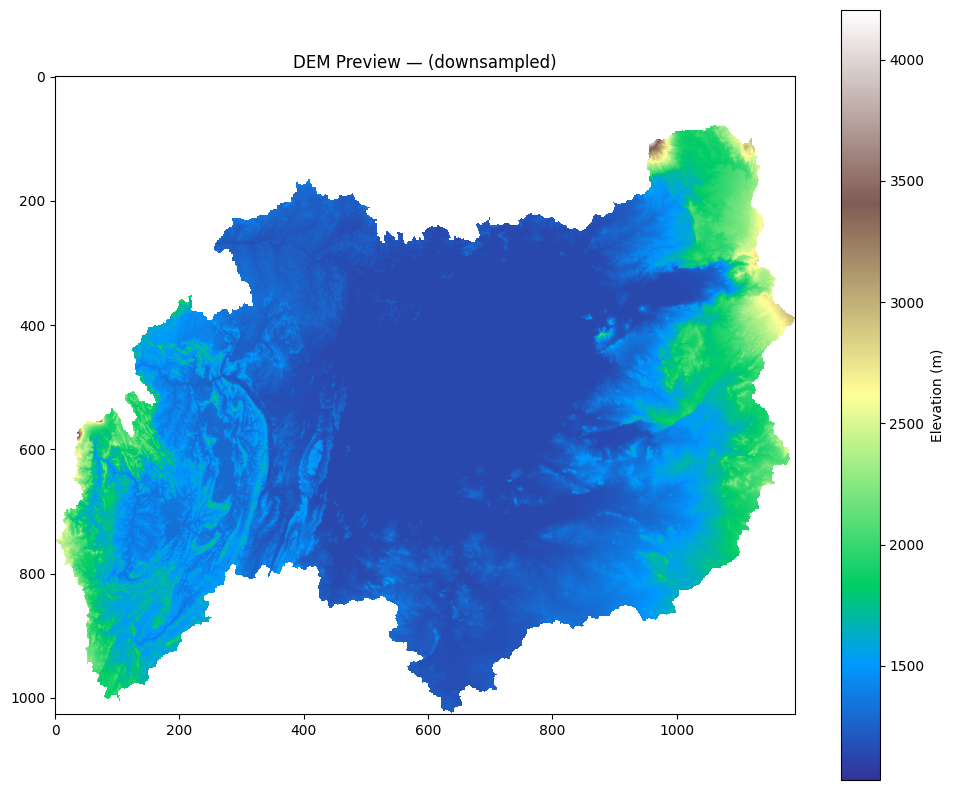

In [9]:
plt.figure(figsize=(10,8))

plt.imshow(quicklook(dem), cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM Preview — (downsampled)")

plt.tight_layout()

plt.savefig(FIG_DIR / "09_raster_preview.png", dpi=200)

plt.show()

### *CELL 7 — Load scenario level series*

In [10]:
baseline_path = DATA_PROCESSED / "06_baseline_agreedcurve_sim.csv"
optimized_path = DATA_PROCESSED / "06_optimized_rulecurve_sim.csv"

baseline_df = pd.read_csv(baseline_path, parse_dates=["date"]).set_index("date")
optimized_df = pd.read_csv(optimized_path, parse_dates=["date"]).set_index("date")

# Vertical datum conversion: convert relative gauge levels to m asl.
REFERENCE_LEVEL_M_ASL = 1122.85

level_obs = baseline_df["level_obs_m_asl"].astype(float) if "level_obs_m_asl" in baseline_df.columns else baseline_df["level_obs_m"].astype(float) + REFERENCE_LEVEL_M_ASL
level_agreed = baseline_df["level_sim_m_asl"].astype(float) if "level_sim_m_asl" in baseline_df.columns else baseline_df["level_sim_m"].astype(float) + REFERENCE_LEVEL_M_ASL
level_opt = optimized_df["level_sim_m_asl"].astype(float) if "level_sim_m_asl" in optimized_df.columns else optimized_df["level_sim_m"].astype(float) + REFERENCE_LEVEL_M_ASL

print(f"Loaded scenario level series in m asl (offset +{REFERENCE_LEVEL_M_ASL:.1f} m).")

Loaded scenario level series in m asl (offset +1122.8 m).


### *CELL 8 — Flood threshold*

In [11]:
H_FLOOD_REL = 12.15
H_FLOOD = H_FLOOD_REL + REFERENCE_LEVEL_M_ASL
print(f"Flood threshold: {H_FLOOD:.3f} m asl (relative {H_FLOOD_REL:.3f} + {REFERENCE_LEVEL_M_ASL:.1f})")

Flood threshold: 1135.000 m asl (relative 12.150 + 1122.8)


### *CELL 9 — Determine peak flood year*

In [12]:
peak_year = level_obs.resample("YS").max().idxmax().year
print("Peak flood year:", peak_year)

Peak flood year: 2020


### *CELL 10 — Determine flood season months*

In [13]:
exceed = (level_obs > H_FLOOD).astype(int)

monthly_exceed = exceed.groupby(level_obs.index.month).sum().sort_values(ascending=False)

monthly_exceed

date
5     165
6     143
7     128
4      96
1      93
3      93
12     93
2      86
8      80
11     75
9      62
10     56
Name: level_obs_m_asl, dtype: int64

In [14]:
flood_season_months = monthly_exceed.head(4).index.sort_values().tolist()

print("Flood season months:", flood_season_months)

Flood season months: [4, 5, 6, 7]


### *CELL 11 — Representative water levels*

In [15]:
def representative_levels(series, name):

    s = series.astype(float)

    peak = s[s.index.year == peak_year].max()

    season = s[s.index.month.isin(flood_season_months)].mean()

    exceed = s[s > H_FLOOD]

    mean_exc = exceed.mean()
    max_exc = exceed.max()

    return {
        "scenario": name,
        "peak_year_level": peak,
        "mean_flood_season_level": season,
        "mean_exceed_level": mean_exc,
        "max_exceed_level": max_exc
    }

rep_levels = pd.DataFrame([
    representative_levels(level_obs,"Observed"),
    representative_levels(level_agreed,"Agreed Curve"),
    representative_levels(level_opt,"Optimized")
])

rep_levels

,scenario,peak_year_level,mean_flood_season_level,mean_exceed_level,max_exceed_level
0,Observed,1136.320000,1134.651617,1135.518821,1136.320000
1,Agreed Curve,1133.110276,1133.831523,NaN,NaN
2,Optimized,1135.545365,1134.565740,1135.345947,1135.564005


### *CELL 12 — Flood mask function*

In [16]:
def flood_mask_preview(dem_preview_arr, water_level_m_asl):
    mask = np.empty(dem_preview_arr.shape, dtype=bool)
    np.isfinite(dem_preview_arr, out=mask)
    np.less_equal(dem_preview_arr, water_level_m_asl, out=mask, where=mask)
    return mask


### *CELL 13 — Flooded area function*

In [17]:
import rasterio

if "dem_res" in globals():
    pixel_x, pixel_y = dem_res
else:
    with rasterio.open(DEM_PATH) as src:
        pixel_x, pixel_y = src.res

def flooded_area(mask):

    cell_area = abs(pixel_x * pixel_y)

    area_m2 = mask.sum() * cell_area

    return area_m2 / 1e6

### *CELL 14 — Generate flood masks*

In [18]:
OFFICIAL_LAKE_SURFACE_AREA_KM2 = 68800.0

extent_rows = []
mask_store = {}
cases = ["peak_year_level", "mean_flood_season_level", "mean_exceed_level"]

for _, row in rep_levels.iterrows():
    scenario = row["scenario"]

    for case in cases:
        level = float(row[case]) if pd.notna(row[case]) else np.nan

        level_m_asl = np.nan
        total_area = np.nan
        net_area = np.nan

        if not np.isnan(level):
            # Safety guard: if levels are still relative (e.g. 9-15), convert to m asl.
            level_m_asl = level + REFERENCE_LEVEL_M_ASL if level < 200 else level
            total_area = flooded_area_km2_chunked(dem_m, level_m_asl, chunk_rows=AREA_CHUNK_ROWS)
            net_area = max(total_area - OFFICIAL_LAKE_SURFACE_AREA_KM2, 0.0)

            if case == "peak_year_level":
                mask_store[(scenario, case)] = flood_mask_preview(dem_preview, level_m_asl)

        extent_rows.append({
            "scenario": scenario,
            "case": case,
            "water_level_m": (level_m_asl - REFERENCE_LEVEL_M_ASL) if pd.notna(level_m_asl) else np.nan,
            "water_level_m_asl": level_m_asl if pd.notna(level_m_asl) else np.nan,
            "official_lake_surface_area_km2": OFFICIAL_LAKE_SURFACE_AREA_KM2,
            "total_flooded_area_km2": total_area,
            "net_flooded_area_km2": net_area,
            "flooded_area_km2": net_area,
        })

extent_summary = pd.DataFrame(extent_rows)

display(extent_summary)


,scenario,case,water_level_m,water_level_m_asl,official_lake_surface_area_km2,total_flooded_area_km2,net_flooded_area_km2,flooded_area_km2
0,Observed,peak_year_level,13.470000,1136.320000,68800.0,69137.457755,337.457755,337.457755
1,Observed,mean_flood_season_level,11.801617,1134.651617,68800.0,68447.448091,0.000000,0.000000
2,Observed,mean_exceed_level,12.668821,1135.518821,68800.0,68821.252111,21.252111,21.252111
3,Agreed Curve,peak_year_level,10.260276,1133.110276,68800.0,67780.670900,0.000000,0.000000
4,Agreed Curve,mean_flood_season_level,10.981523,1133.831523,68800.0,68099.253227,0.000000,0.000000
5,Agreed Curve,mean_exceed_level,NaN,NaN,68800.0,NaN,NaN,NaN
6,Optimized,peak_year_level,12.695365,1135.545365,68800.0,68831.697975,31.697975,31.697975
7,Optimized,mean_flood_season_level,11.715740,1134.565740,68800.0,68414.538651,0.000000,0.000000
8,Optimized,mean_exceed_level,12.495947,1135.345947,68800.0,68754.541385,0.000000,0.000000


### *CELL 15 — Save extent summary*

In [19]:
extent_summary.to_csv(
    TAB_DIR / "09_flood_extent_summary.csv",
    index=False
)

print("Saved flood extent summary.")

Saved flood extent summary.


### *CELL 16 — Peak flood comparison panel*

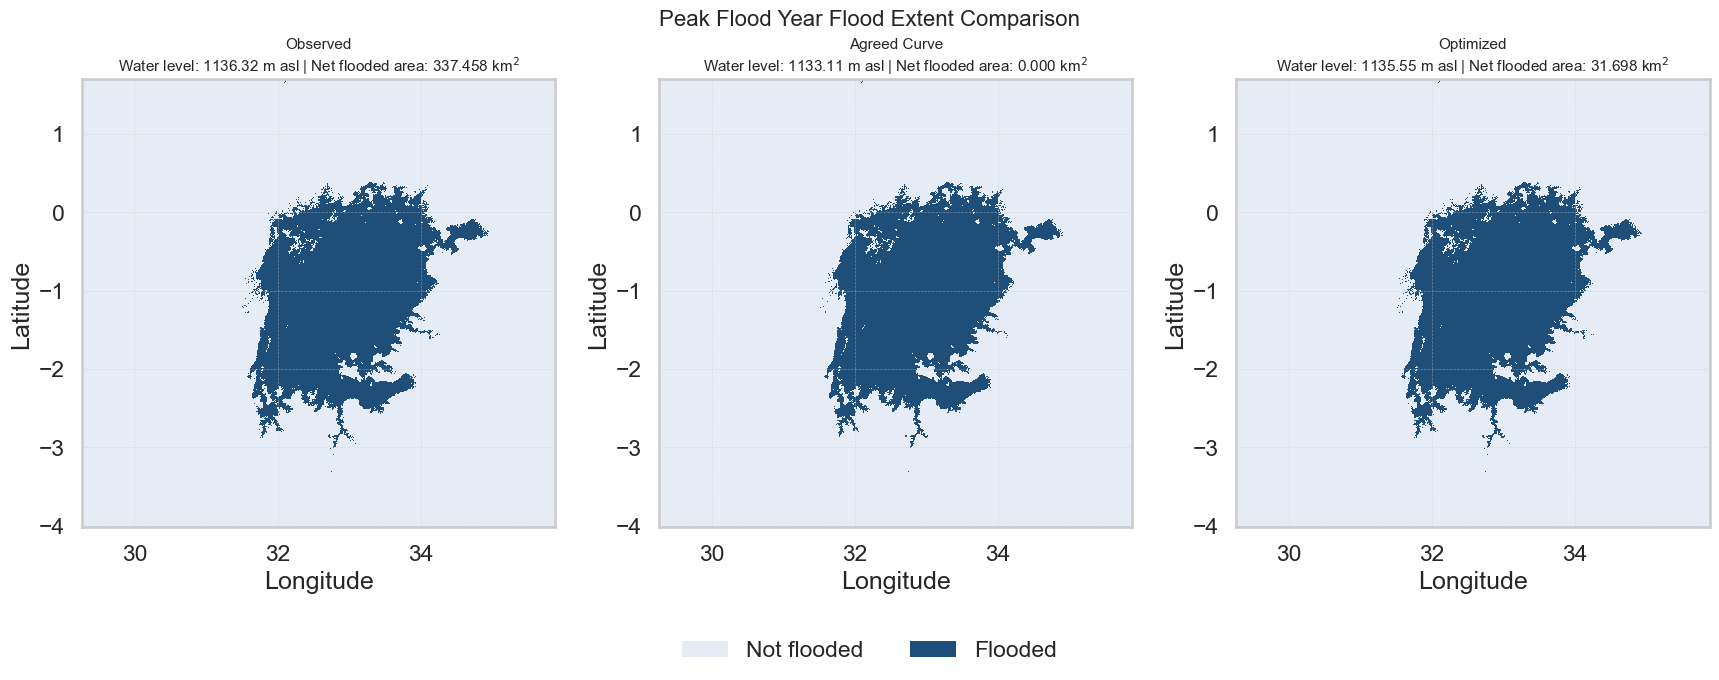

In [20]:
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Optional seaborn style for cleaner visuals
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except Exception:
    pass

scenarios = ["Observed", "Agreed Curve", "Optimized"]
fig, axes = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=False)

# 0 = not flooded, 1 = flooded
flood_cmap = ListedColormap(["#E6ECF5", "#1F4E79"])

for ax, scen in zip(axes, scenarios):

    mask_preview = mask_store[(scen, "peak_year_level")].astype(int)

    ax.imshow(
        mask_preview,
        cmap=flood_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
        extent=dem_preview_extent,
        origin="upper",
        aspect="auto",
    )

    row = extent_summary[
        (extent_summary["scenario"] == scen)
        & (extent_summary["case"] == "peak_year_level")
    ]

    if not row.empty:
        area_km2 = float(row["net_flooded_area_km2"].iloc[0])
        wl_m_asl = float(row["water_level_m_asl"].iloc[0])
        subtitle = f"Water level: {wl_m_asl:.2f} m asl | Net flooded area: {area_km2:.3f} km$^2$"
    else:
        subtitle = "No summary available"

    ax.set_title(f"{scen}\n{subtitle}", fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

legend_handles = [
    Patch(facecolor="#E6ECF5", edgecolor="none", label="Not flooded"),
    Patch(facecolor="#1F4E79", edgecolor="none", label="Flooded"),
]
fig.subplots_adjust(bottom=0.24, top=0.88, wspace=0.22)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=False,
)
fig.suptitle("Peak Flood Year Flood Extent Comparison", fontsize=16)

plt.savefig(
    FIG_DIR / "09_peak_year_flood_extent_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

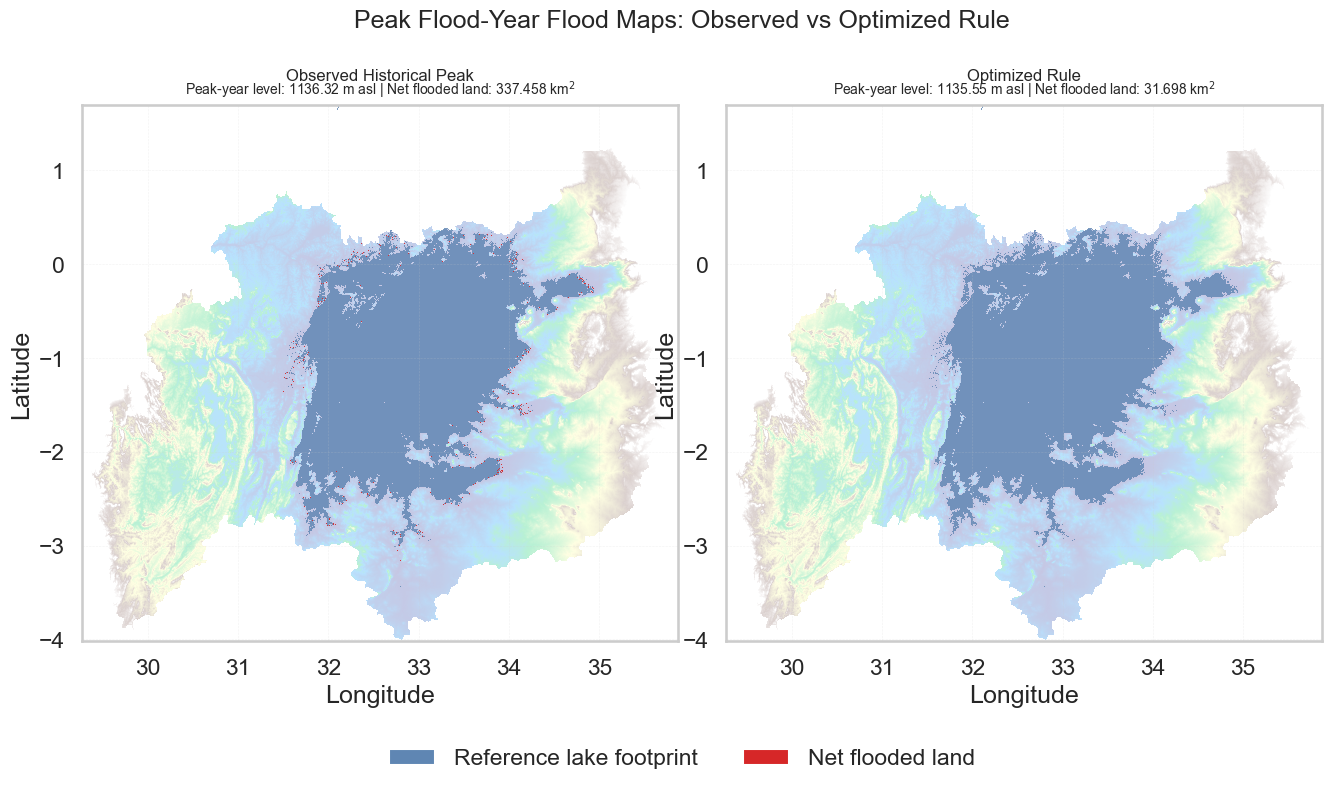

,peak_year_level_m_asl,net_flooded_land_km2
scenario,,
Observed,1136.320000,337.457755
Optimized,1135.545365,31.697975


In [25]:
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

scenarios = ["Observed", "Optimized"]
panel_titles = {
    "Observed": "Observed Historical Peak",
    "Optimized": "Optimized Rule",
}

peak_rows = (
    extent_summary.loc[
        extent_summary["case"].eq("peak_year_level")
        & extent_summary["scenario"].isin(scenarios)
    ]
    .copy()
    .set_index("scenario")
)

if peak_rows.shape[0] != 2:
    raise ValueError("Expected Observed and Optimized peak-year rows in extent_summary.")

if "flood_stats" in globals() and not flood_stats.empty:
    area_curve = (
        flood_stats[["water_level_m_asl", "flooded_area_km2"]]
        .dropna()
        .sort_values("flooded_area_km2")
    )
else:
    area_curve = None

if area_curve is not None and (
    area_curve["flooded_area_km2"].min()
    <= OFFICIAL_LAKE_SURFACE_AREA_KM2
    <= area_curve["flooded_area_km2"].max()
):
    reference_level_m_asl = float(
        np.interp(
            OFFICIAL_LAKE_SURFACE_AREA_KM2,
            area_curve["flooded_area_km2"],
            area_curve["water_level_m_asl"],
        )
    )
else:
    lower = float(np.nanmin(peak_rows["water_level_m_asl"])) - 1.0
    upper = float(np.nanmax(peak_rows["water_level_m_asl"]))
    for _ in range(18):
        mid = 0.5 * (lower + upper)
        area_mid = flooded_area_km2_chunked(dem_m, mid, chunk_rows=AREA_CHUNK_ROWS)
        if area_mid < OFFICIAL_LAKE_SURFACE_AREA_KM2:
            lower = mid
        else:
            upper = mid
    reference_level_m_asl = 0.5 * (lower + upper)

reference_lake_mask = flood_mask_preview(dem_preview, reference_level_m_asl)
dem_background = np.ma.masked_invalid(dem_preview)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=False)

reference_cmap = ListedColormap(["#5F86B3"])
net_flood_cmap = ListedColormap(["#D62728"])

bg_vmin = float(np.nanpercentile(dem_preview, 5))
bg_vmax = float(np.nanpercentile(dem_preview, 95))

for ax, scen in zip(axes, scenarios):
    scen_mask = mask_store[(scen, "peak_year_level")]
    net_flood_mask = np.logical_and(scen_mask, ~reference_lake_mask)

    ax.imshow(
        dem_background,
        cmap="terrain",
        extent=dem_preview_extent,
        origin="upper",
        aspect="auto",
        alpha=0.28,
        vmin=bg_vmin,
        vmax=bg_vmax,
    )
    ax.imshow(
        np.ma.masked_where(~reference_lake_mask, reference_lake_mask),
        cmap=reference_cmap,
        extent=dem_preview_extent,
        origin="upper",
        aspect="auto",
        interpolation="nearest",
        alpha=0.82,
    )
    ax.imshow(
        np.ma.masked_where(~net_flood_mask, net_flood_mask),
        cmap=net_flood_cmap,
        extent=dem_preview_extent,
        origin="upper",
        aspect="auto",
        interpolation="nearest",
        alpha=0.92,
    )

    wl_m_asl = float(peak_rows.loc[scen, "water_level_m_asl"])
    net_area_km2 = float(peak_rows.loc[scen, "net_flooded_area_km2"])

    ax.set_title(panel_titles[scen], fontsize=12, pad=18)
    ax.text(
        0.5,
        1.01,
        f"Peak-year level: {wl_m_asl:.2f} m asl | Net flooded land: {net_area_km2:.3f} km$^2$",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle="--", linewidth=0.45, alpha=0.25)

legend_handles = [
    Patch(facecolor="#5F86B3", edgecolor="white", label="Reference lake footprint"),
    Patch(facecolor="#D62728", edgecolor="white", label="Net flooded land"),
]

fig.subplots_adjust(bottom=0.19, top=0.86, wspace=0.08)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=2,
    frameon=False,
)
fig.suptitle("Peak Flood-Year Flood Maps: Observed vs Optimized Rule", fontsize=18)

plt.savefig(
    FIG_DIR / "09_peak_flood_maps_observed_vs_optimized_true_metrics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

peak_rows[["water_level_m_asl", "net_flooded_area_km2"]].rename(
    columns={
        "water_level_m_asl": "peak_year_level_m_asl",
        "net_flooded_area_km2": "net_flooded_land_km2",
    }
)


### *CELL 17 — Flooded area bar chart*

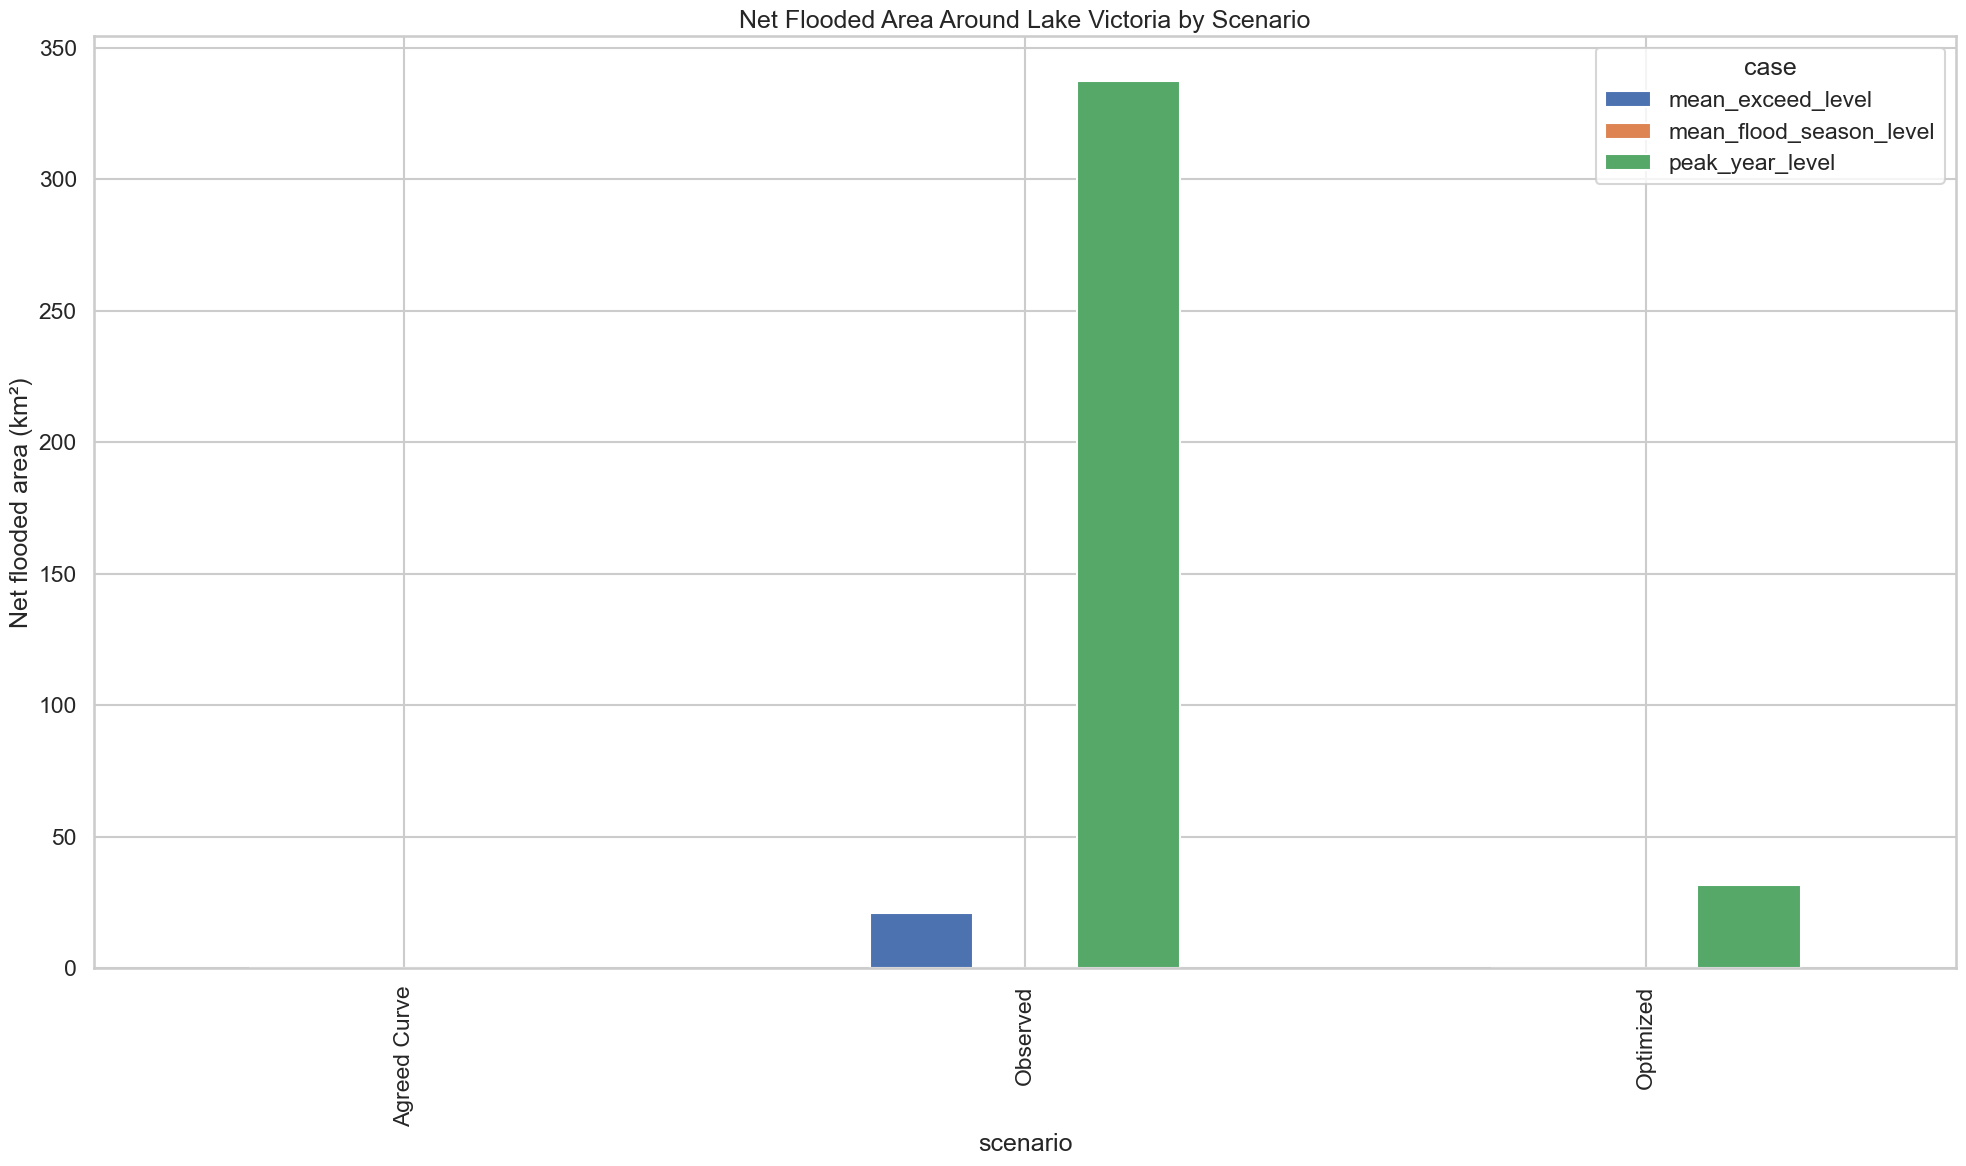

In [21]:
pivot = extent_summary.pivot(
    index="scenario",
    columns="case",
    values="net_flooded_area_km2"
)

pivot.plot(kind="bar",figsize=(20,12))

plt.title("Net Flooded Area Around Lake Victoria by Scenario")

plt.ylabel("Net flooded area (km²)")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "09_flood_extent_area_bar.png",
    dpi=200
)

plt.show()

### *CELL 18 — Comparing the Net Flooded Land area between Observed Vs Optimized rules*

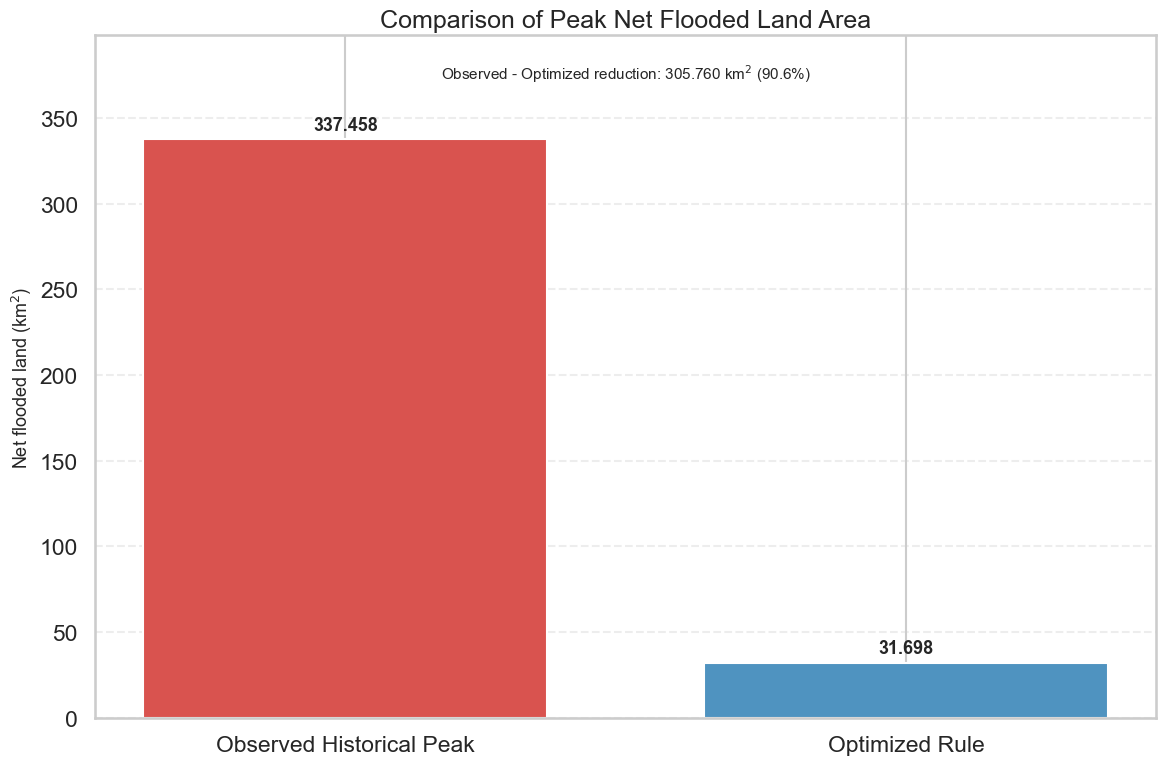

,scenario,water_level_m_asl,net_flooded_area_km2
0,Observed,1136.320000,337.457755
6,Optimized,1135.545365,31.697975


In [22]:
peak_compare = (
    extent_summary.loc[
        extent_summary["case"].eq("peak_year_level")
        & extent_summary["scenario"].isin(["Observed", "Optimized"]),
        ["scenario", "water_level_m_asl", "net_flooded_area_km2"],
    ]
    .copy()
)

if peak_compare.shape[0] != 2:
    raise ValueError("Expected Observed and Optimized rows for 'peak_year_level'.")

order = {"Observed": 0, "Optimized": 1}
label_map = {
    "Observed": "Observed Historical Peak",
    "Optimized": "Optimized Rule",
}
color_map = {
    "Observed": "#D9534F",
    "Optimized": "#4F93C0",
}

peak_compare["label"] = peak_compare["scenario"].map(label_map)
peak_compare = peak_compare.sort_values("scenario", key=lambda s: s.map(order))

observed_area = float(
    peak_compare.loc[
        peak_compare["scenario"] == "Observed", "net_flooded_area_km2"
    ].iloc[0]
)
optimized_area = float(
    peak_compare.loc[
        peak_compare["scenario"] == "Optimized", "net_flooded_area_km2"
    ].iloc[0]
)
reduction_km2 = observed_area - optimized_area
reduction_pct = (reduction_km2 / observed_area) * 100 if observed_area else 0.0

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(
    peak_compare["label"],
    peak_compare["net_flooded_area_km2"],
    color=[color_map[s] for s in peak_compare["scenario"]],
    width=0.72,
)

ax.set_title("Comparison of Peak Net Flooded Land Area", fontsize=18)
ax.set_ylabel("Net flooded land (km$^2$)", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.set_ylim(0, peak_compare["net_flooded_area_km2"].max() * 1.18)

for bar, area in zip(bars, peak_compare["net_flooded_area_km2"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + peak_compare["net_flooded_area_km2"].max() * 0.01,
        f"{area:.3f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

ax.text(
    0.5,
    0.96,
    (
        f"Observed - Optimized reduction: {reduction_km2:.3f} km$^2$ "
        f"({reduction_pct:.1f}%)"
    ),
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "09_peak_net_flood_comparison_observed_vs_optimized.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

peak_compare[["scenario", "water_level_m_asl", "net_flooded_area_km2"]]


### *CELL 19 — Thesis-ready paragraph*

In [23]:
txt = f"""
Raster-based inundation analysis using the surrounding-land DEM
was applied to evaluate spatial flood extent under
observed, Agreed Curve, and optimized Lake Victoria regulation
scenarios.

All reported flooded areas represent net flooded area around the lake,
computed after subtracting the official Lake Victoria surface area of
68,800 km2 from the total inundated area implied by each water level.

The peak flood year ({peak_year}) produced the largest inundation
extent under the observed scenario. The optimized rule curve reduced
net flooded area relative to observed conditions while avoiding the
excessive drawdown associated with the Agreed Curve counterfactual.

These spatial flood extent results reinforce the time-series flood
metrics presented in Notebook 08, demonstrating that the optimized
release policy reduces flood risk exposure while maintaining realistic
lake level dynamics.
"""

out = TAB_DIR / "09_flood_extent_results_paragraph.txt"
out.write_text(txt)

print(txt)



Raster-based inundation analysis using the surrounding-land DEM
was applied to evaluate spatial flood extent under
observed, Agreed Curve, and optimized Lake Victoria regulation
scenarios.

All reported flooded areas represent net flooded area around the lake,
computed after subtracting the official Lake Victoria surface area of
68,800 km2 from the total inundated area implied by each water level.

The peak flood year (2020) produced the largest inundation
extent under the observed scenario. The optimized rule curve reduced
net flooded area relative to observed conditions while avoiding the
excessive drawdown associated with the Agreed Curve counterfactual.

These spatial flood extent results reinforce the time-series flood
metrics presented in Notebook 08, demonstrating that the optimized
release policy reduces flood risk exposure while maintaining realistic
lake level dynamics.

